<h1>Table of contents</h1>

<div class="alert alert-block alert-info" style="margin-top: 20px">
    <ol>
        <li><a href="#Data">Data</a></li>
        <li><a href="#Selecting-And-Preprocessing">Selecting And Preprocessing</a></li>
        <li><a href="#Model">Model</a></li>
        <li><a href="#Evaluation">Evaluation</a></li>
        <li><a href="#-Multi-Poly-Model-">Multi Poly Model</a></li>
        <li><a href="#Multi-Poly-Evaluation">Multi Poly Evaluation</a></li>
    </ol>
</div>
<br>
<hr>

# import libs

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from scipy.stats import norm
from sklearn.preprocessing import PolynomialFeatures
from sklearn import linear_model
from sklearn.metrics import r2_score

<h1 id="Data">Data</h1>

In [2]:
df = pd.read_csv("../data/FuelConsumption.csv")
df

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1062,2014,VOLVO,XC60 AWD,SUV - SMALL,3.0,6,AS6,X,13.4,9.8,11.8,24,271
1063,2014,VOLVO,XC60 AWD,SUV - SMALL,3.2,6,AS6,X,13.2,9.5,11.5,25,264
1064,2014,VOLVO,XC70 AWD,SUV - SMALL,3.0,6,AS6,X,13.4,9.8,11.8,24,271
1065,2014,VOLVO,XC70 AWD,SUV - SMALL,3.2,6,AS6,X,12.9,9.3,11.3,25,260


In [3]:
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


In [4]:
cdf = df[["ENGINESIZE","CYLINDERS","FUELCONSUMPTION_COMB","CO2EMISSIONS"]]
cdf

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
0,2.0,4,8.5,196
1,2.4,4,9.6,221
2,1.5,4,5.9,136
3,3.5,6,11.1,255
4,3.5,6,10.6,244
...,...,...,...,...
1062,3.0,6,11.8,271
1063,3.2,6,11.5,264
1064,3.0,6,11.8,271
1065,3.2,6,11.3,260


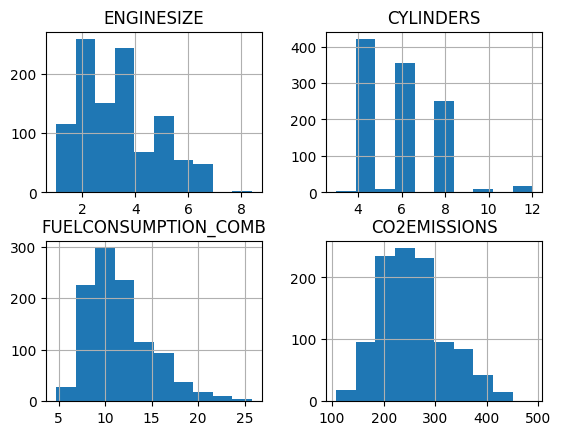

In [5]:
cdf.hist()
plt.show()

<h1 id="Selecting-And-Preprocessing">Selecting And Preprocessing</h1>

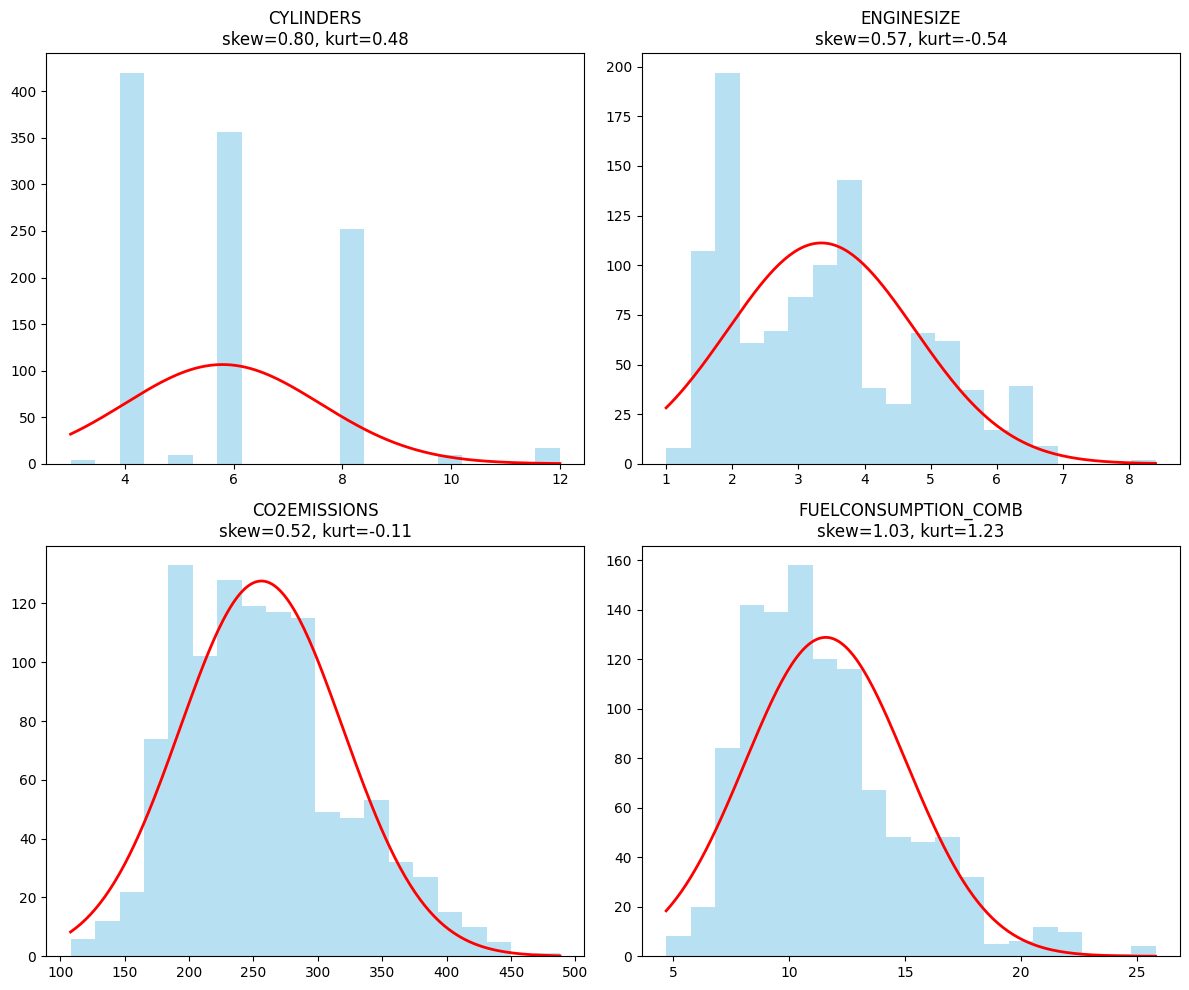

In [6]:
viz = cdf[['CYLINDERS','ENGINESIZE','CO2EMISSIONS','FUELCONSUMPTION_COMB']]

plt.figure(figsize=(12,10))

for i, col in enumerate(viz.columns):
    data = viz[col]
    mu = data.mean()
    sigma = data.std()
    
    skew = data.skew()
    kurt = data.kurt()

    plt.subplot(2, 2, i+1)

    counts, bins, _ = plt.hist(data, bins=20, alpha=0.6, color='skyblue')

    x = np.linspace(data.min(), data.max(), 200)
    y = norm.pdf(x, mu, sigma)
    
    y = y * len(data) * (bins[1] - bins[0]) # for scaling to normal count
    plt.plot(x, y, 'r', linewidth=2)
    plt.title(f"{col}\nskew={skew:.2f}, kurt={kurt:.2f}")

plt.tight_layout()
plt.show()

<h4><b>Creating train and test</b></h4>

In [7]:
mask = np.random.randn(len(cdf)) < 0.8
train = cdf[mask]
test = cdf[~mask]

<h1 id="Model">Model</h1>

In [17]:
train_x = np.asanyarray(train[["ENGINESIZE"]])
train_y = np.asanyarray(train[["CO2EMISSIONS"]])

poly = PolynomialFeatures(degree=2)
train_x_poly = poly.fit_transform(train_x)
train_x_poly

array([[ 1.  ,  2.  ,  4.  ],
       [ 1.  ,  2.4 ,  5.76],
       [ 1.  ,  1.5 ,  2.25],
       ...,
       [ 1.  ,  3.  ,  9.  ],
       [ 1.  ,  3.  ,  9.  ],
       [ 1.  ,  3.2 , 10.24]], shape=(843, 3))

In [18]:
regr = linear_model.LinearRegression()
train_y_ = regr.fit(train_x_poly,train_y)
print ('Coefficients: ', regr.coef_)
print ('Intercept: ',regr.intercept_)

Coefficients:  [[ 0.         49.28701516 -1.35815243]]
Intercept:  [109.78981099]


Text(0, 0.5, 'Emission')

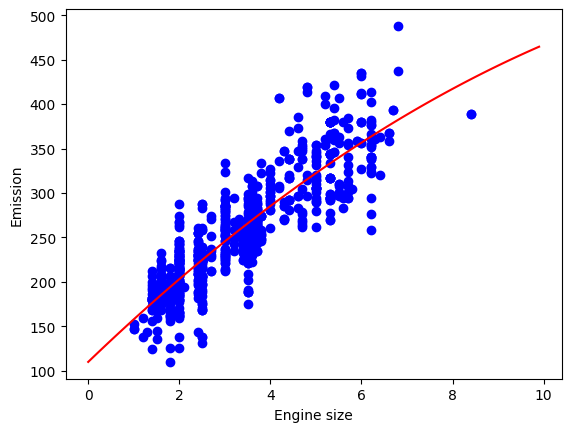

In [19]:
plt.scatter(train.ENGINESIZE, train.CO2EMISSIONS,  color='blue')
XX = np.arange(0.0, 10.0, 0.1)
yy = regr.intercept_[0]+ regr.coef_[0][1]*XX+ regr.coef_[0][2]*np.power(XX, 2)
plt.plot(XX, yy, '-r' )
plt.xlabel("Engine size")
plt.ylabel("Emission")

<h2 id="evaluation">Evaluation</h2>

In [20]:
test_x = np.asanyarray(test[["ENGINESIZE"]])
test_y = np.asanyarray(test[["CO2EMISSIONS"]])

test_x_poly = poly.fit_transform(test_x)
test_y_ = regr.predict(test_x_poly)

print("Mean absolute error: %.2f" % np.mean(np.absolute(test_y_ - test_y)))
print("Residual sum of squares (MSE): %.2f" % np.mean((test_y_ - test_y) ** 2))
print("R2-score: %.2f" % r2_score(test_y,test_y_ ) )

Mean absolute error: 24.25
Residual sum of squares (MSE): 1024.01
R2-score: 0.77


<h1 id = "-Multi-Poly-Model-" > Multi Poly Model </h1>

In [21]:
train_x_M = np.asanyarray(train[["ENGINESIZE","FUELCONSUMPTION_COMB"]])
train_y_M = np.asanyarray(train[["CO2EMISSIONS"]])

poly_M = PolynomialFeatures(degree=2)
train_x_poly_M = poly_M.fit_transform(train_x_M)
train_x_poly_M

array([[  1.  ,   2.  ,   8.5 ,   4.  ,  17.  ,  72.25],
       [  1.  ,   2.4 ,   9.6 ,   5.76,  23.04,  92.16],
       [  1.  ,   1.5 ,   5.9 ,   2.25,   8.85,  34.81],
       ...,
       [  1.  ,   3.  ,  11.8 ,   9.  ,  35.4 , 139.24],
       [  1.  ,   3.  ,  11.8 ,   9.  ,  35.4 , 139.24],
       [  1.  ,   3.2 ,  12.8 ,  10.24,  40.96, 163.84]], shape=(843, 6))

In [22]:
regr_M = linear_model.LinearRegression()
train_y_M_ = regr_M.fit(train_x_poly_M,train_y_M)
print ('Coefficients: ', regr_M.coef_)
print ('Intercept: ',regr_M.intercept_)

Coefficients:  [[  0.         -28.07633461  36.75489931  -5.62610484   6.79372267
   -1.92582264]]
Intercept:  [-10.39822798]


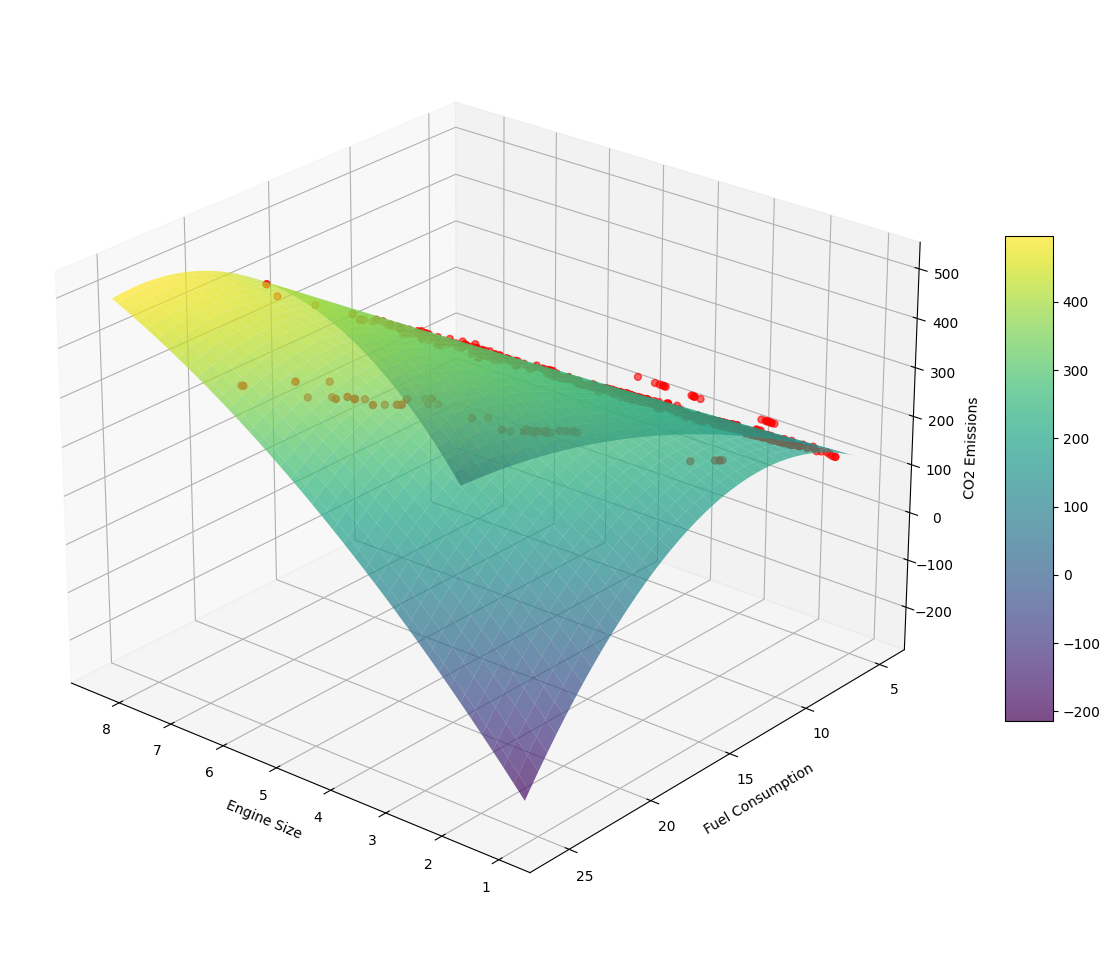

In [24]:
X1 = train["ENGINESIZE"]
X2 = train["FUELCONSUMPTION_COMB"]
Y  = train["CO2EMISSIONS"]

# smoother grid
x1_range = np.linspace(X1.min(), X1.max(), 80)
x2_range = np.linspace(X2.min(), X2.max(), 80)
x1_grid, x2_grid = np.meshgrid(x1_range, x2_range)

grid = np.c_[x1_grid.ravel(), x2_grid.ravel()]
grid_poly = poly_M.transform(grid)

y_pred = regr_M.predict(grid_poly)
y_pred_grid = y_pred.reshape(x1_grid.shape)

fig = plt.figure(figsize=(12,10))
ax = fig.add_subplot(111, projection='3d')

# real data
ax.scatter(X1, X2, Y, color="Red", s=25, alpha=0.6)

# polynomial surface
surf = ax.plot_surface(
    x1_grid,
    x2_grid,
    y_pred_grid,
    cmap="viridis",
    alpha=0.7,
    edgecolor="none"
)

ax.set_xlabel("Engine Size")
ax.set_ylabel("Fuel Consumption")
ax.set_zlabel("CO2 Emissions")

ax.view_init(elev=25, azim=130)

fig.colorbar(surf, shrink=0.5, aspect=10)

plt.tight_layout()
plt.show()

<h2 id="Multi-Poly-Evaluation">Multi Poly Evaluation</h2>

In [25]:
test_x_M = np.asanyarray(test[["ENGINESIZE","FUELCONSUMPTION_COMB"]])
test_y_M = np.asanyarray(test[["CO2EMISSIONS"]])

test_x_poly_M = poly_M.fit_transform(test_x_M)
test_y_M_ = regr_M.predict(test_x_poly_M)

print("Mean absolute error: %.2f" % np.mean(np.absolute(test_y_M_ - test_y_M)))
print("Residual sum of squares (MSE): %.2f" % np.mean((test_y_M_ - test_y_M) ** 2))
print("R2-score: %.2f" % r2_score(test_y_M,test_y_M_ ) )

Mean absolute error: 11.21
Residual sum of squares (MSE): 433.23
R2-score: 0.90
